In [1]:
#άσκηση 2η
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import IPython
import sounddevice as sd
import soundfile as sf

Text(0.5, 1.0, 'Speech Utterance')

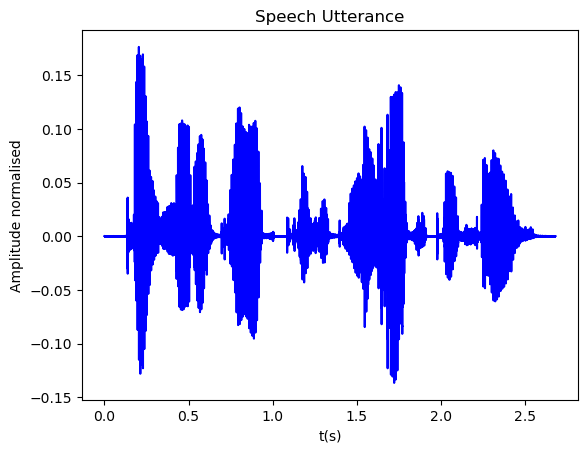

In [2]:
#2.1
x_normalised, fs = sf.read('speech_utterance.wav', dtype='float64')

t = 1/fs * np.arange(len(x_normalised)) #x_normalised(nTs)
plt.plot(t, x_normalised, color='blue')
plt.xlabel('t(s)')
plt.ylabel('Amplitude normalised')
plt.title("Speech Utterance")

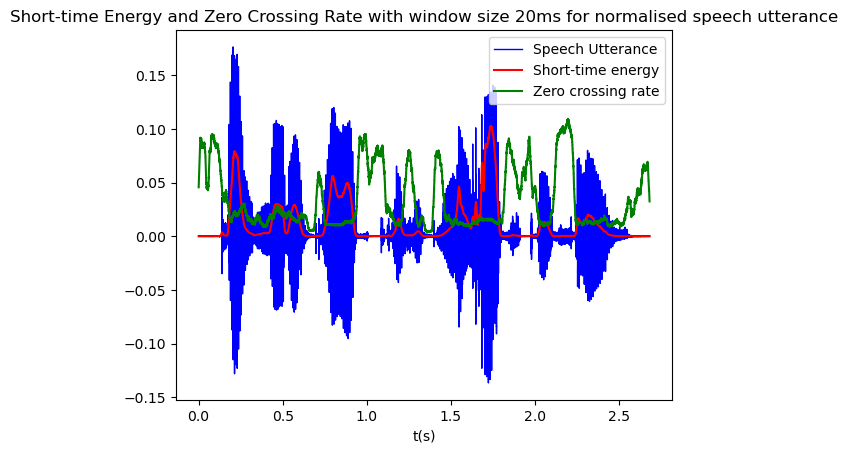

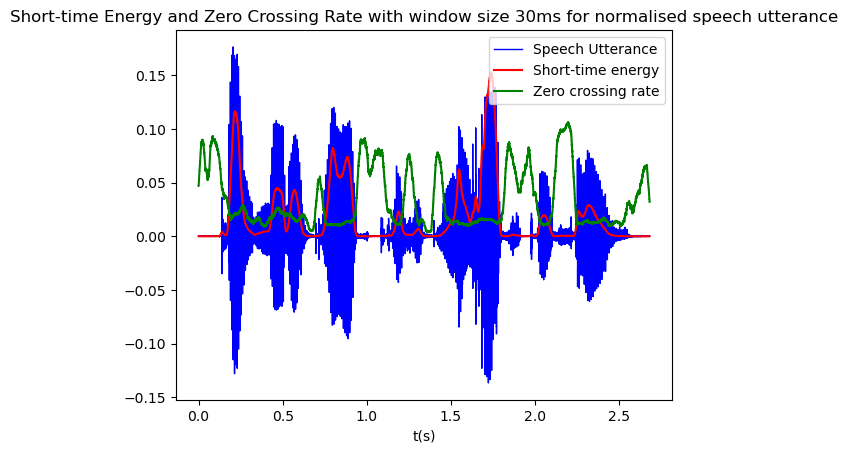

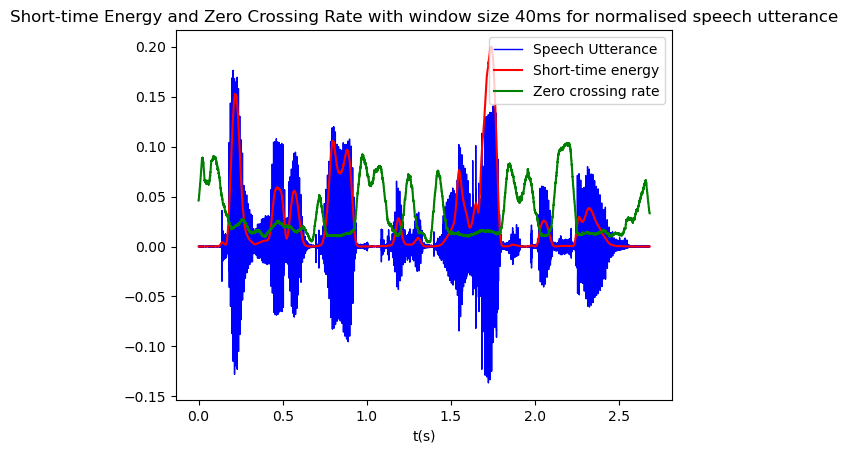

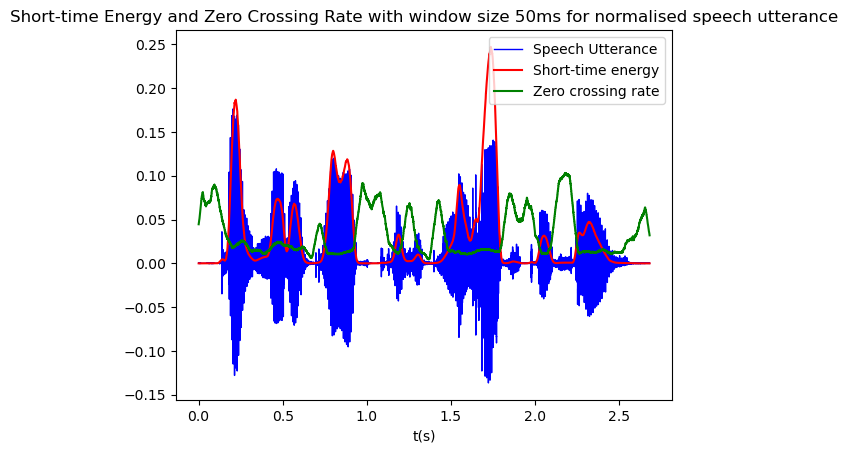

In [3]:
#2.2
#υπολογισμός ενέργειας βραχέους χρόνου, συνέλιξη x^2[n] με window
x_square = x_normalised**2
#hamming_window μήκους 20,30,40,50ms ή 320,480,640,800 δείγματα αν fs = 16kHz αφού n = t/Ts
number_of_samples = [320, 480, 640, 800]

hamming_windows = []

for n in number_of_samples:
    hamming_windows.append(np.hamming(n))
    
e_n = []

#η παράμετρος same κάνει τη συνάρτηση να επιστρέφει μήκος συνέλιξης ίσο με το max των δύο άρα του x
for h in hamming_windows:
    e_n.append(np.convolve(x_square, h, 'same'))
               
#υπολογισμός ρυθμού αλλαγής προσήμου

rectangle_windows = []
for n in number_of_samples:
    rectangle_windows.append(1/(2*n) * np.ones(n))


#το zero crossing rate είναι ουσιαστικά η συνέλιξη των rect παραθύρων με το σήμα sign(x(n))
# - sign(x(n-1)), οπότε φτίαχνουμε το sign(x(n)) πρώτα και μετά χρησιμοποιούμε την np.diff
#που κάνει αυτήν την δουλειά, βέβαια επιστρέφει array μεγέθους μικρότερο κατά ένα και για
#αυτό κάνουμε insert στην αρχή το sign(x[0]) = sign(x[0]) - 0 που χρειαζόμαστε

z_n = []

term = np.sign(x_normalised)
term = np.diff(term)
term = np.insert(term, 0, np.sign(x_normalised[0]))
term = np.abs(term)

for r in rectangle_windows:
    z_n.append(np.convolve(term, r, 'same'))

#plotting
for i in range(0, 4):
    plt.figure(i)
    ax = plt.gca()
    plt.plot(t, x_normalised, label='Speech Utterance', color ='blue', linewidth=1)
    plt.plot(t, e_n[i]/5, label='Short-time energy', color ='red', linewidth = 1.5) #scaling factor for short term energy and ZCR = 5
    #αν κανονικοποιούσαμε (απλώς την κλιμακώνουμε) την ενέργεια δεν θα φαινόταν το προφανές ότι για 
    #μεγαλύτερο μήκος του παραθύρου έχω μεγαλύτερη ενέργεια (περισσότερα δείγματα)
    plt.plot(t, z_n[i]/5, label = 'Zero crossing rate', color ='green', linewidth = 1.5)
    plt.xlabel('t(s)')
    plt.legend(loc='upper right')
    plt.title(f'Short-time Energy and Zero Crossing Rate with window size {i+2}0ms for normalised speech utterance')

Text(0.5, 1.0, 'Short-time Energy with window size 20ms for beginning silence')

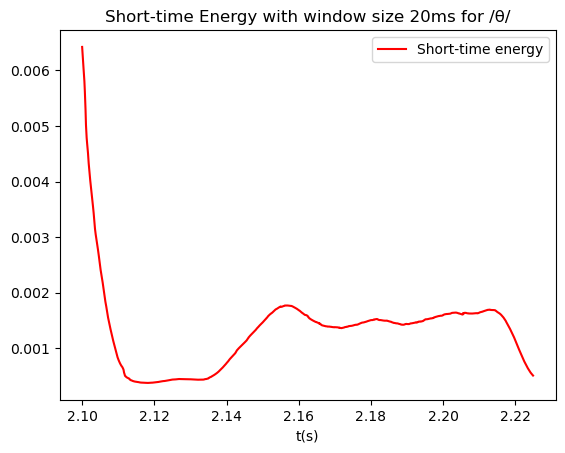

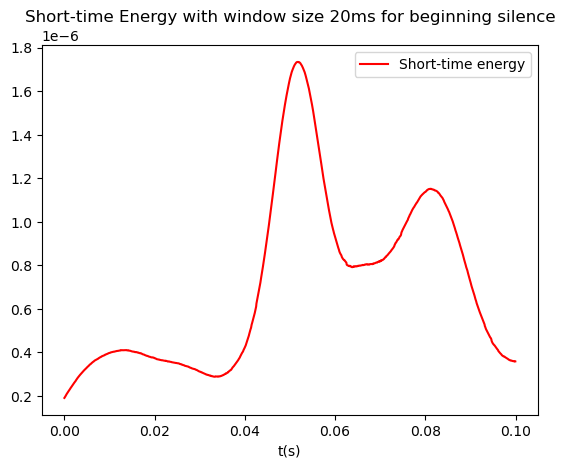

In [4]:
#2.2 συνέχεια, απόδειξη παρατήρησης σχετικά με την διάκριση των ενεργειών των άφωνων ήχων και της σιωπής
plt.figure(0)
ax = plt.gca()
#plt.plot(t[33600:36000], x_normalised[33600:36000], label='Speech Utterance', color ='blue', linewidth=1)
plt.plot(t[33600:35600], e_n[0][33600:35600], label='Short-time energy', color ='red', linewidth = 1.5) 
#plt.plot(t[33600:35600], z_n[0][33600:35600], label = 'Zero crossing rate', color ='green', linewidth = 1.5)
plt.xlabel('t(s)')
plt.legend(loc='upper right')
plt.title(f'Short-time Energy with window size 20ms for /θ/')
plt.figure(1)
#plt.plot(t[33600:36000], x_normalised[33600:36000], label='Speech Utterance', color ='blue', linewidth=1)
plt.plot(t[:1600], e_n[0][:1600], label='Short-time energy', color ='red', linewidth = 1.5) 
#plt.plot(t[:1600], z_n[0][:1600], label = 'Zero crossing rate', color ='green', linewidth = 1.5)
plt.xlabel('t(s)')
plt.legend(loc='upper right')
plt.title(f'Short-time Energy with window size 20ms for beginning silence')

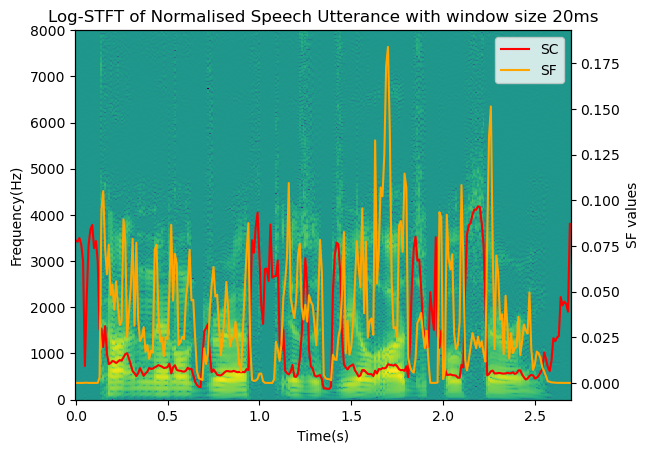

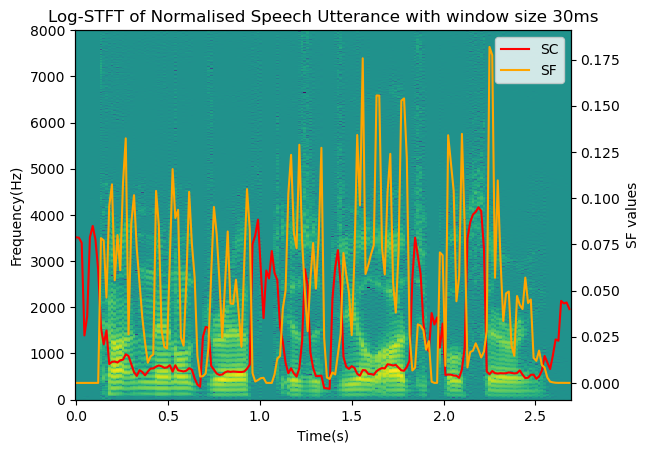

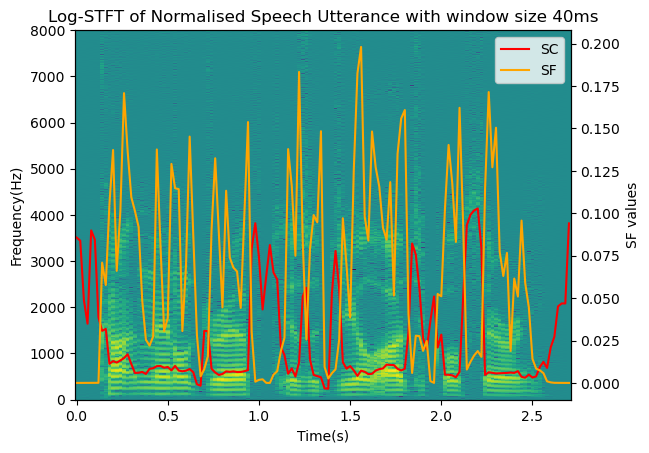

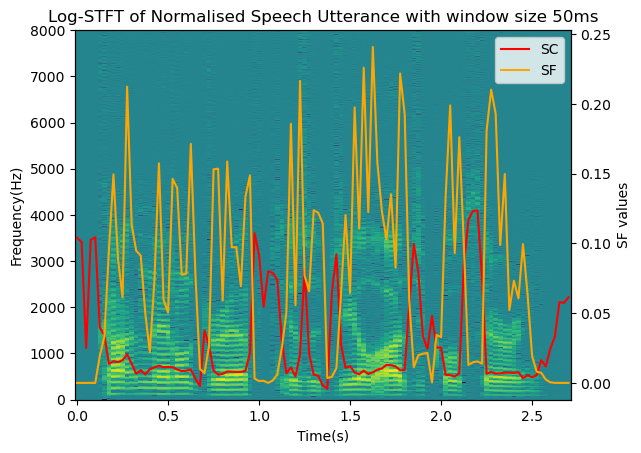

In [5]:
#2.3
frequency_bins = []
time_frames = []
STFT_array = []
for n in number_of_samples:
    f,ti,S = sp.signal.stft(x_normalised,fs=16000,nperseg=n,noverlap=n/2, nfft = 2048)
    #print(f.shape, ti.shape, S.shape) όταν αυξάνουμε τα δείγματα των παραθύρων στα οποία υπολογίζουμε τους DFT
    #παρατηρούμε ότι ο αριθμ΄ός των time frames μειώνεται και επομένως έχουμε χειρότερο time resolution όπως φαίνεται και παρακάτω
    frequency_bins.append(f)
    time_frames.append(ti)
    STFT_array.append(S)

#Spectral centroid
idx = 0
spectral_centroids_all = []
k = np.arange(1025) #k από 0 έως 1024
for stft in STFT_array:
    spectral_centroids = []
    S_current = np.abs(stft) ** 2
    for m in range(0, len(time_frames[idx])): 
         sum_1 = np.sum(k * (S_current[k, m])) #αριθμητής
         sum_2 = np.sum(S_current[k, m]) #κανονικοποιημένος DFT
         spectral_centroids.append((sum_1 / sum_2 ) * (16000/2048))
    spectral_centroids_all.append(spectral_centroids)
    idx += 1

#Spectral Flux
idx = 0
spectral_flux_all = []
for stft in STFT_array:
    spectral_flux = []
    S_current = np.abs(stft) ** 2 
    sum_1 = np.sum(S_current[k,0]) #για m = -1 όπου κρατάω μόνο το πρώτο vector
    vector_1 = S_current[k, 0] / (sum_1+0.0001) #σταθερά για να μην εκτινάσσεται το μέγεθος, στην αναφορά παίζουμε και με άλλες σταθερές
    spectral_flux.append(np.linalg.norm(vector_1))
    for m in range(0, len(time_frames[idx])-1):
        sum_1 = np.sum(S_current[k,m+1]) #παρανομαστής πρώτου διανύσματος γραμμής
        sum_2 = np.sum(S_current[k,m]) #παρανομαστής δεύτερου
        vector_1 = S_current[k, m+1] / (sum_1+0.0001) 
        vector_2 = S_current[k,m] / (sum_2+0.0001) 
        vector = vector_1 - vector_2
        spectral_flux.append(np.linalg.norm(vector)) #νόρμα 2
    spectral_flux_all.append(spectral_flux)
    idx += 1

count = 4 #figure count
idx = 0
#η μεγα΄λύτερη συχνότητα που μπορώ να αναπαραστήσω είναι fs/2 = 8kHz, nyquist, βέβαια η φωνή δεν πάει παραπάνω από 
#τα 4kHz
for stft in STFT_array:
    plt.figure(count)
    ax1 = plt.gca()
    count += 1
    ax1.pcolormesh(time_frames[idx],frequency_bins[idx],np.log10(np.abs(stft+0.0001))) #small constant is added for numerical stability
    pl1 = ax1.plot(time_frames[idx], spectral_centroids_all[idx], color = 'red', label='SC')
    #το SF έχει πολύ μικρότερες τιμές
    ax2 = ax1.twinx()
    pl2 = ax2.plot(time_frames[idx], spectral_flux_all[idx], color = 'orange', label ='SF')
    pls = pl1 + pl2
    leg = [l.get_label() for l in pls]
    ax1.legend(pls, leg, loc='upper right')
    ax1.set_xlabel('Time(s)')
    ax1.set_ylabel('Frequency(Hz)')
    ax2.set_ylabel('SF values')
    plt.title(f'Log-STFT of Normalised Speech Utterance with window size {number_of_samples[idx]//16}ms')
    idx += 1

Text(0.5, 1.0, 'Log-STFT του άφωνου /θ/ window size 20ms')

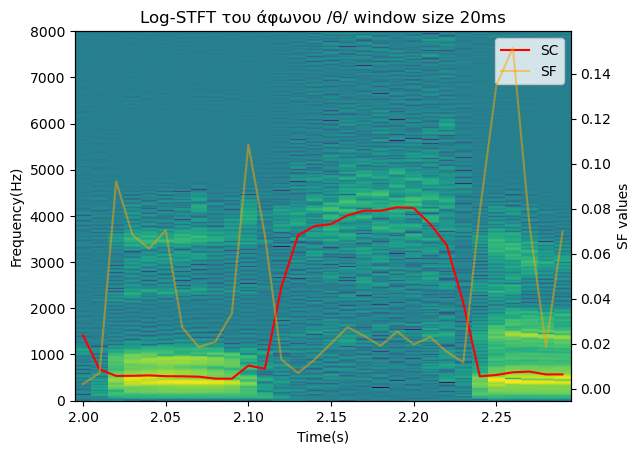

In [6]:
#2.3 συνέχεια
#επιβεβαίωνεται το γεγονός ότι έχουμε το άφωνο /θ/, με την ένταση του χρώματος να συγκεντρώνεται στις υψηλές συχνότητες
#φαίνεται επίσης και από το που κάθεται το SC
#καθώς μεταβάλλεται το φασματικό περιεχόμενο αφού αλλάζουμε γράμμα έχουμε αύξηση του SF μετά μείωση-μηδενισμό όσο κρατιέται αυτός ο τόνος και μετά
#πάλι αύξηση όταν συναντήσει τα έμφωνα /e/, /o/ -> πυκνό χρώμα στις χαμηλές συχνότητες -> μεγάλη ενέργεια
idx = 0

plt.figure(count)
ax1 = plt.gca()
count += 1
ax1.pcolormesh(time_frames[idx][200:230],frequency_bins[idx],np.log10(np.abs(STFT_array[0][:,200:230]+0.0001))) #small constant is added for numerical stability
pl1 = ax1.plot(time_frames[idx][200:230], spectral_centroids_all[idx][200:230], color = 'red',  label='SC')
#το SF έχει πολύ μικρότερες τιμές
ax2 = ax1.twinx()
pl2 = ax2.plot(time_frames[idx][200:230], spectral_flux_all[idx][200:230], color = 'orange', label ='SF', alpha = 0.5)
pls = pl1 + pl2
leg = [l.get_label() for l in pls]
ax1.legend(pls, leg, loc='upper right')
ax1.set_xlabel('Time(s)')
ax1.set_ylabel('Frequency(Hz)')
ax2.set_ylabel('SF values')
plt.title(f'Log-STFT του άφωνου /θ/ window size {number_of_samples[idx]//16}ms')

Text(0.5, 1.0, 'Good Company, Queen')

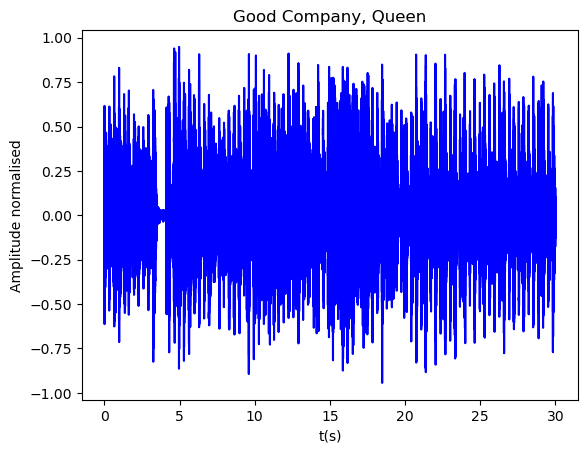

In [7]:
#2.4.1
x_normalised, fs = sf.read('music.wav', dtype='float64')

t = 1/fs * np.arange(len(x_normalised)) #x_normalised(nTs)
plt.plot(t, x_normalised, color='blue')
plt.xlabel('t(s)')
plt.ylabel('Amplitude normalised')
plt.title("Good Company, Queen")

In [ ]:
#2.4.2
x_square = x_normalised**2
#hamming_window μήκους 20,30,40,50ms ή 320,480,640,800 δείγματα αν fs = 16kHz αφού n = t/Ts
samples_of_samples = [320, 480, 640, 800]
    
hamming_windows = []
    
for n in number_of_samples:
    hamming_windows.append(np.hamming(n))
        
e_n = []
    
for h in hamming_windows:
    e_n.append(np.convolve(x_square, h, 'same'))
                   
    
rectangle_windows = []
for n in samples_of_samples:
    rectangle_windows.append(1/(2*n) * np.ones(n))
        
z_n = []
    
term = np.sign(x_normalised)
term = np.diff(term)
term = np.insert(term, 0, np.sign(x_normalised[0]))
term = np.abs(term)
    
for r in rectangle_windows:
    z_n.append(np.convolve(term, r, 'same'))
    
#plotting
#scaling short term energy energy for each window, bigger windows length means higher energy
scaling_factor = [15, 20, 25, 30]
for i in range(0, 4):
    plt.figure(i)
    ax = plt.gca()
    ax.plot(t, e_n[i]/scaling_factor[i], label='Short-time energy', color ='red', linewidth = 1.5)
    ax.plot(t, x_normalised, label='Music', color ='blue', linewidth=1.5)
    ax.plot(t, z_n[i], label = 'Zero crossing rate', color ='green', linewidth = 1.5)
    plt.xlabel('t(s)')
    plt.legend(loc='upper right')
    plt.title(f'Short-time Energy and Zero Crossing Rate with window size {i+2}0ms for normalised music')

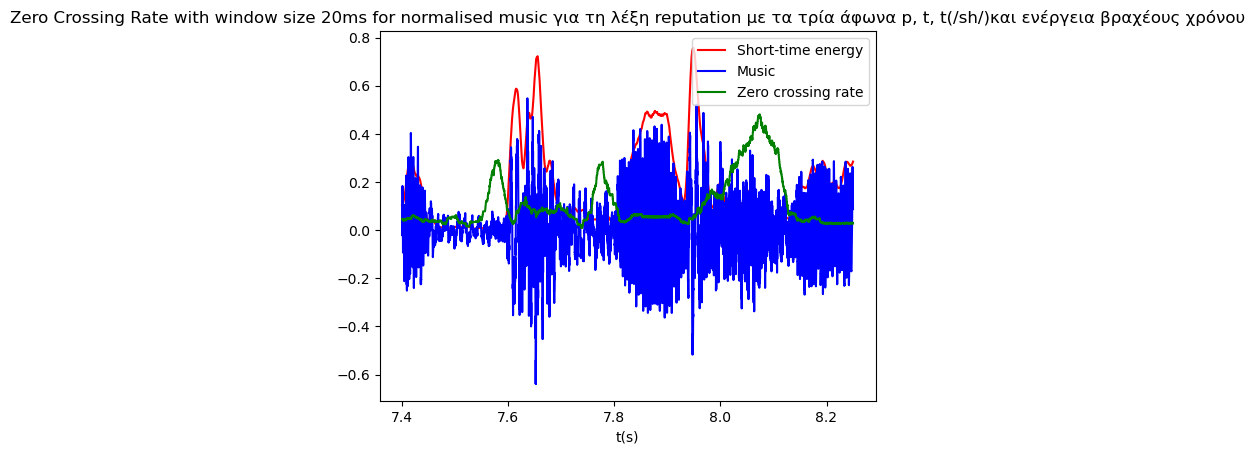

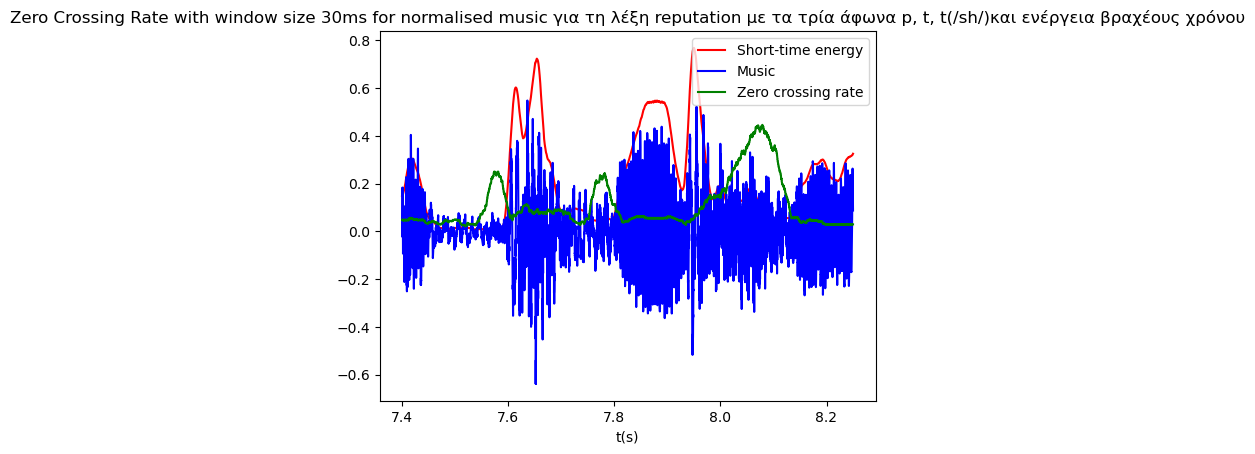

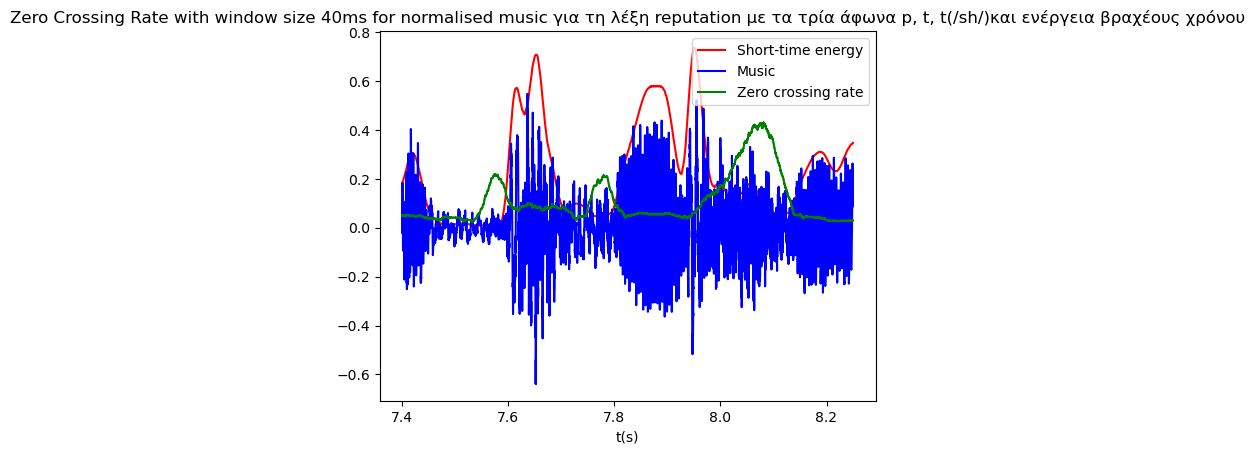

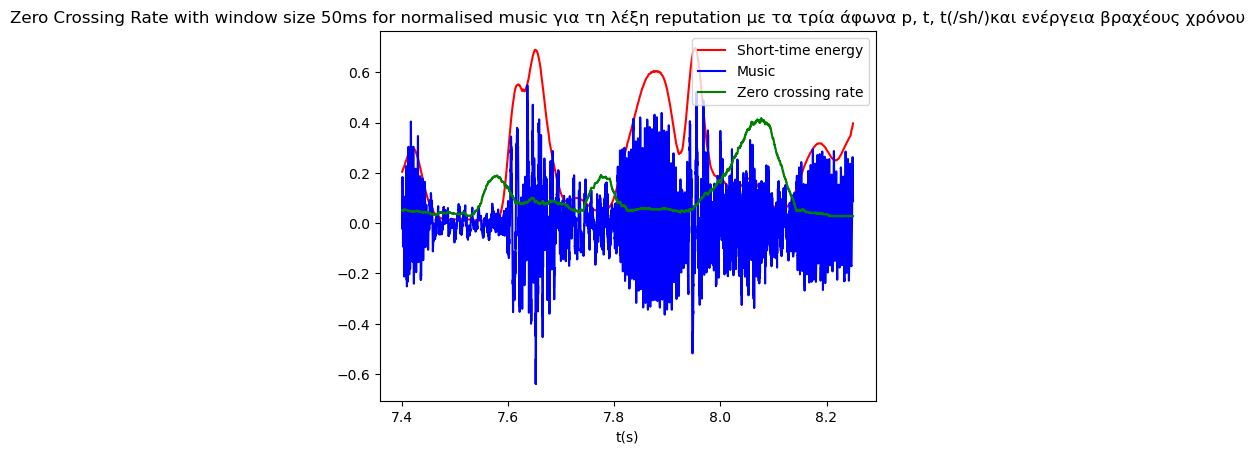

In [ ]:
#2.4.2 συνέχεια λέξη reputation
count = 4 #figure count
#sf.write("reputation.wav", x_normalised[118400: 133000], 16000)
for i in range(0, 4):
    plt.figure(count)
    count += 1
    ax = plt.gca()
    ax.plot(t[118400:132000], e_n[i][118400:132000]/scaling_factor[i], label='Short-time energy', color ='red', linewidth = 1.5)
    ax.plot(t[118400:132000], x_normalised[118400:132000], label='Music', color ='blue', linewidth=1.5)
    ax.plot(t[118400:132000], z_n[i][118400:132000], label = 'Zero crossing rate', color ='green', linewidth = 1.5)
    plt.xlabel('t(s)')
    plt.legend(loc='upper right')
    
    plt.title(f'Zero Crossing Rate with window size {i+2}0ms for normalised music για τη λέξη reputation με τα τρία άφωνα p, t, t(/sh/)και ενέργεια βραχέους χρόνου')

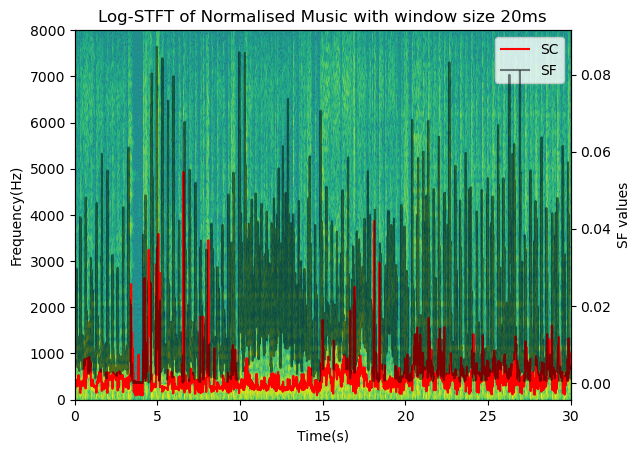

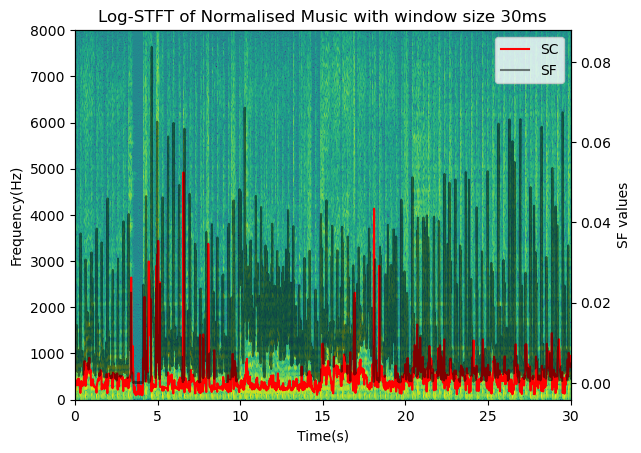

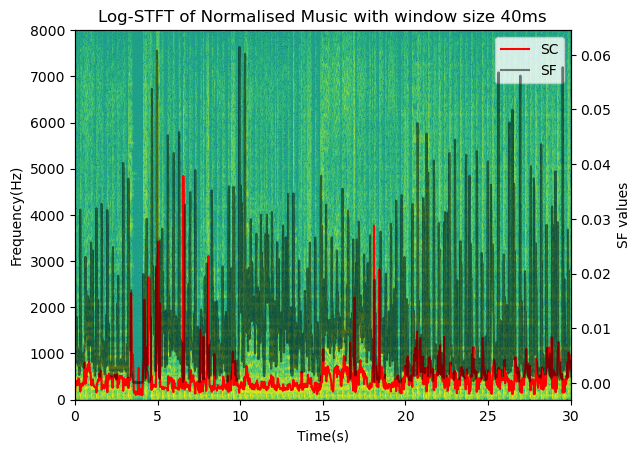

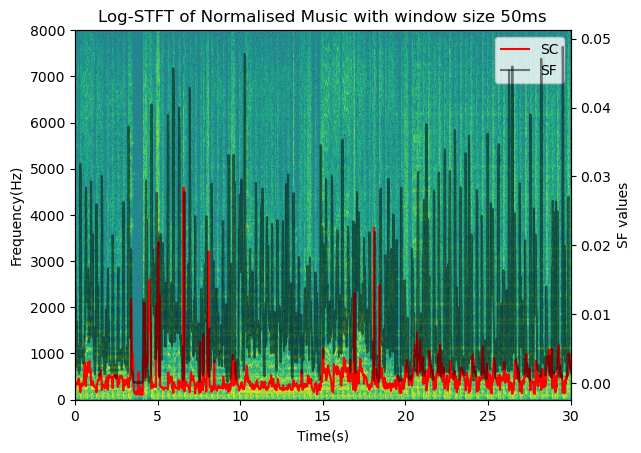

In [ ]:
#2.4.3
frequency_bins = []
time_frames = []
STFT_array = []
for n in number_of_samples:
    f,ti,S = sp.signal.stft(x_normalised,fs=16000,nperseg=n,noverlap=n/2, nfft = 2048)
    frequency_bins.append(f)
    time_frames.append(ti)
    STFT_array.append(S)

#Spectral centroid
idx = 0
spectral_centroids_all = []
k = np.arange(1025) #k από 0 έως 1024
for stft in STFT_array:
    spectral_centroids = []
    S_current = np.abs(stft) ** 2
    for m in range(0, len(time_frames[idx])): 
         sum_1 = np.sum(k * (S_current[k, m])) #αριθμητής
         sum_2 = np.sum(S_current[k, m]) #κανονικοποιημένος DFT
         spectral_centroids.append((sum_1 / sum_2 ) * (16000/2048))
    spectral_centroids_all.append(spectral_centroids)
    idx += 1

#Spectral Flux
idx = 0
spectral_flux_all = []
for stft in STFT_array:
    spectral_flux = []
    S_current = np.abs(stft) ** 2
    sum_1 = np.sum(S_current[k,0]) #για m = -1 όπου κρατάω μόνο το πρώτο vector
    vector_1 = S_current[k, 0] / (sum_1+1) #στη μουσική χρειάζεται μεγαλύτερη σταθερά στον παρανομαστή
    spectral_flux.append(np.linalg.norm(vector_1))
    for m in range(0, len(time_frames[idx])-1):
        sum_1 = np.sum(S_current[k,m+1]) #παρανομαστής πρώτου διανύσματος γραμμής
        sum_2 = np.sum(S_current[k,m]) #παρανομαστής δεύτερου
        vector_1 = S_current[k, m+1] / (sum_1+1) 
        vector_2 = S_current[k,m] / (sum_2+1) 
        vector = vector_1 - vector_2
        spectral_flux.append(np.linalg.norm(vector)) #νόρμα 2
    spectral_flux_all.append(spectral_flux)
    idx += 1

count = 8 #figure count
idx = 0
#η μεγα΄λύτερη συχνότητα που μπορώ να αναπαραστήσω είναι fs/2 = 8kHz, nyquist rate για να μην έχω aliasing, βέβαια η φωνή δεν πάει παραπάνω από 
#τα 4kHz
#στην αναφορά φαίνονται καλύτερα γιατί έχουμε απομονώσει τα μεγέθη για καλύτερη παρατήρηση
for stft in STFT_array:
    plt.figure(count)
    ax1 = plt.gca()
    count += 1
    ax1.pcolormesh(time_frames[idx],frequency_bins[idx],np.log10(np.abs(stft+0.0001))) #small constant is added for numerical stability
    pl1 = ax1.plot(time_frames[idx], spectral_centroids_all[idx], color = 'red',  label='SC')
    #το SF έχει πολύ μικρότερες τιμές
    ax2 = ax1.twinx()
    pl2 = ax2.plot(time_frames[idx], spectral_flux_all[idx], color = 'black', label ='SF', alpha = 0.5)
    pls = pl1 + pl2
    leg = [l.get_label() for l in pls]
    ax1.legend(pls, leg, loc='upper right')
    ax1.set_xlabel('Time(s)')
    ax1.set_ylabel('Frequency(Hz)')
    ax2.set_ylabel('SF values')
    plt.title(f'Log-STFT of Normalised Music with window size {number_of_samples[idx]//16}ms')
    idx += 1

Text(0.5, 1.0, 'Log-STFT of word "reputation" with window size 20ms')

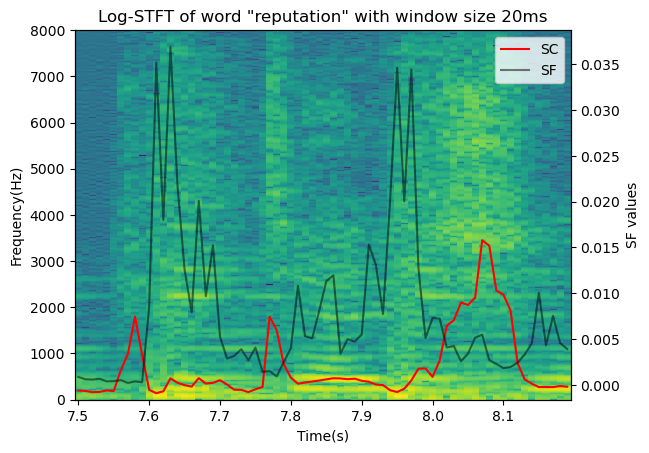

In [ ]:
#2.4.3 συνέχεια STFT reputation
idx = 0

plt.figure(count)
ax1 = plt.gca()
count += 1
ax1.pcolormesh(time_frames[idx][750:820],frequency_bins[idx],np.log10(np.abs(STFT_array[0][:,750:820]+0.0001))) #small constant is added for numerical stability
pl1 = ax1.plot(time_frames[idx][750:820], spectral_centroids_all[idx][750:820], color = 'red',  label='SC')
#το SF έχει πολύ μικρότερες τιμές
ax2 = ax1.twinx()
pl2 = ax2.plot(time_frames[idx][750:820], spectral_flux_all[idx][750:820], color = 'black', label ='SF', alpha = 0.5)
pls = pl1 + pl2
leg = [l.get_label() for l in pls]
ax1.legend(pls, leg, loc='upper right')
ax1.set_xlabel('Time(s)')
ax1.set_ylabel('Frequency(Hz)')
ax2.set_ylabel('SF values')
plt.title(f'Log-STFT of word "reputation" with window size {number_of_samples[idx]//16}ms')